In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
run /home/ih/pychfpga/pychfpga/pocket_correlator.py --serial 0055 --stderr_log_level debug --prog 2

Enabling nested event loop on current loop ID 126340450937248
Checking network settings for UDP data reception...
Will attempt to discover CRS board with serial number 0055
Looking for CRS board with serial number 0055...
Error during CRS board discovery: Use AsyncServiceInfo.async_request from the event loop
Falling back to standard interface detection...
Using interface: enp6s0

✓ Network settings verified - ready for UDP data reception
Adding new log handlers of <Logger pychfpga (WARNING)> with level debug
+--------------+-----------------+
| Standalone   | Virt. slot None |
| Motherboards | CRS_SN0055      |
|              | 192.168.88.198  |
+--------------+-----------------+
+--------------+-----------------+

TCPipe: Programming FPGA with 34437356 bytes


<pychfpga.fpga_firmware.chfpga.ct_engine.uct_engine.UCTEngine object at 0x72e7c86ad850>: CT engine only supports packaging 16 frame per packet. 2 frames are not supported


UCAP mode is set to 0


In [5]:
board_inputs = [f'ADC{n + 1}' for n in range(8)]
board_inputs

['ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5', 'ADC6', 'ADC7', 'ADC8']

In [6]:
pc.i.get_temperatures()

{'FPGA_core': 52.19286994934083}

In [7]:
d_adc = pc.read_adc_frames(n_frames = 100)

In [8]:
rms_voltage_LSBs = np.array([np.sqrt((1/(d_adc.shape[1]*d_adc.shape[2]))*np.sum(d_adc[n].flatten()**2)) for n in range(8)])
rms_voltage_V = rms_voltage_LSBs*(1/2**14)
rms_power_lin = rms_voltage_V**2/100
rms_power_dBm = 10*np.log10(rms_power_lin/1e-3)
rms_power_dBm

array([-60.57065987, -60.74978801, -60.64947082, -60.90512779,
       -60.10442605, -59.12337622, -60.82864605, -60.36885161])

In [9]:
d_adc[0]

array([[  1,   1,  -7, ...,  -2,  -1,  -9],
       [  5,  -1,   1, ...,   4,   5,  -1],
       [  5,   9,  -3, ...,  -2,  -3,   1],
       ...,
       [ -3,   3,  -3, ...,  -5,  -3,  -3],
       [  7,   1,   7, ...,   1,  -1,   5],
       [  9,   3,  -1, ..., -13,  -3,   1]], dtype=int16)

In [10]:
d_adc_psd = np.mean(np.abs(np.fft.rfft(d_adc))**2, axis = 1)

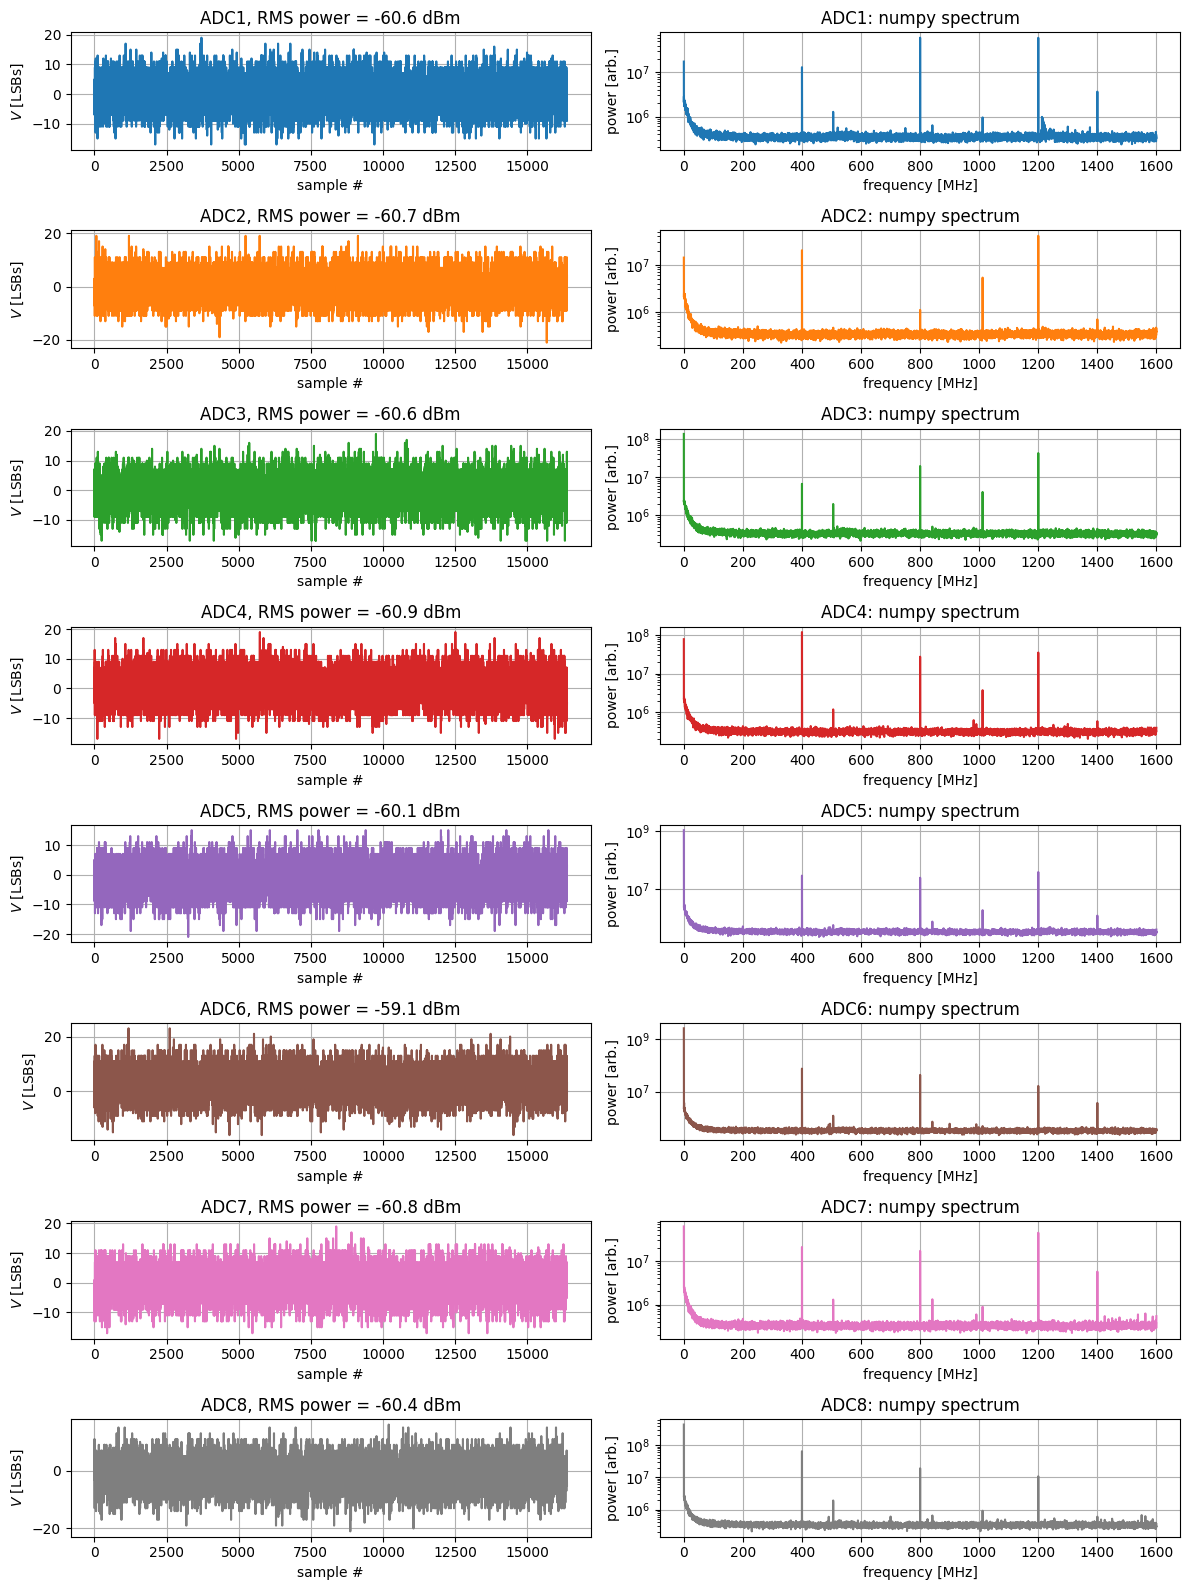

In [11]:
plt.figure(figsize = (12, 16))
for n in range(pc.NPOLS):

    plt.subplot(8, 2, 2*n + 1)
    plt.title(f'{board_inputs[n]}, RMS power = {np.round(rms_power_dBm[n], 1)} dBm')
    plt.plot(d_adc[n, 0], color = f'C{n}')
    plt.ylabel('$V$ [LSBs]')
    plt.xlabel('sample #')
    plt.grid()
        
    plt.subplot(8, 2, 2*n + 2)
    plt.title(f'{board_inputs[n]}: numpy spectrum')
    plt.semilogy(pc.f, d_adc_psd[n][:-1], color = f'C{n}')
    plt.ylabel('power [arb.]')
    plt.xlabel('frequency [MHz]')
    plt.grid()
            
plt.tight_layout()